<a href="https://colab.research.google.com/github/xMrTuffnut/ai-companion-wellbeing/blob/main/notebooks/04_rq3_disclosure_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RQ3: How are self-disclosure and offline social network related to well-being?
**Owner: Person D**

Rules: only the owner edits this notebook. Before saving to GitHub: *Runtime → Restart and run all*.

In [1]:
# ---- Shared setup cell: same in every notebook, don't change it alone ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")

# Raw data (original study). Once data/clean.csv exists, switch to CLEAN_URL.
RAW_URL = "https://raw.githubusercontent.com/SALT-NLP/AI-companionship-well-being/main/data.csv"
CLEAN_URL = "https://raw.githubusercontent.com/xMrTuffnut/ai-companion-wellbeing/main/data/clean.csv"

df = pd.read_csv(CLEAN_URL)
print(df.shape)

(1131, 17)


In [2]:
# Save a figure and download it (then upload it to figures/ on GitHub)
def save_fig(name):
    plt.savefig(name, dpi=200, bbox_inches="tight")
    try:
        from google.colab import files
        files.download(name)
    except ImportError:
        pass  # not in Colab: file is saved next to the notebook

## RQ3: How are self-disclosure and offline social network related to well-being?
**Step 1: Correlations.** The heatmap shows how strongly each pair of variables moves together (−1 to +1).

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

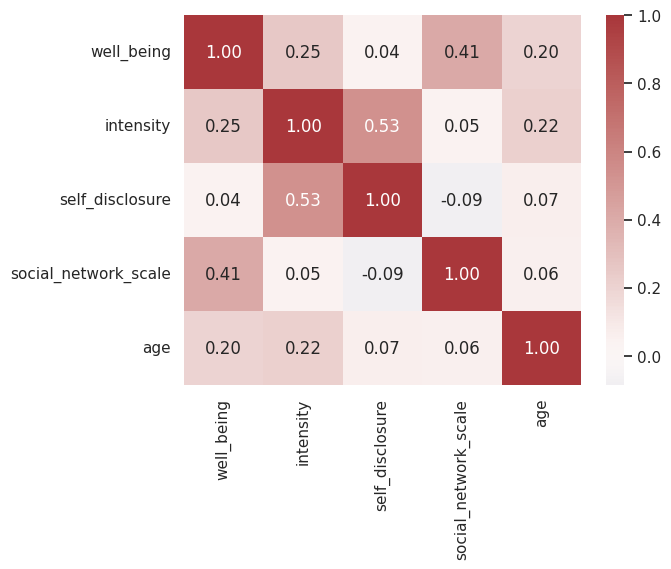

In [3]:
cols = ["well_being", "intensity", "self_disclosure", "social_network_scale", "age"]
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
save_fig("rq3_corr_heatmap.png")

**Step 2: Multiple regression.** We look at all predictors together, so each coefficient shows the effect of one variable while the others are held constant. The standardized predictors are read per 1 standard deviation; age per year; single compared with being in a relationship.

In [4]:
model = smf.ols("well_being ~ self_disclosure + social_network_scale + intensity + age + single",
                data=df).fit()
print(f"R² = {model.rsquared:.3f}, n = {int(model.nobs)}")

results = pd.DataFrame({"coef": model.params,
                        "ci_low": model.conf_int()[0],
                        "ci_high": model.conf_int()[1],
                        "p": model.pvalues}).round(3)
results

R² = 0.255, n = 1131


,coef,ci_low,ci_high,p
Intercept,4.550,4.329,4.772,0.000
self_disclosure,-0.074,-0.154,0.007,0.072
social_network_scale,0.496,0.428,0.564,0.000
intensity,0.294,0.212,0.376,0.000
age,0.012,0.006,0.019,0.000
single,-0.350,-0.491,-0.208,0.000


**Step 3: Coefficient plot.** Each dot is one effect; the line is its 95% confidence interval. If the line crosses zero, the effect is not significant.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

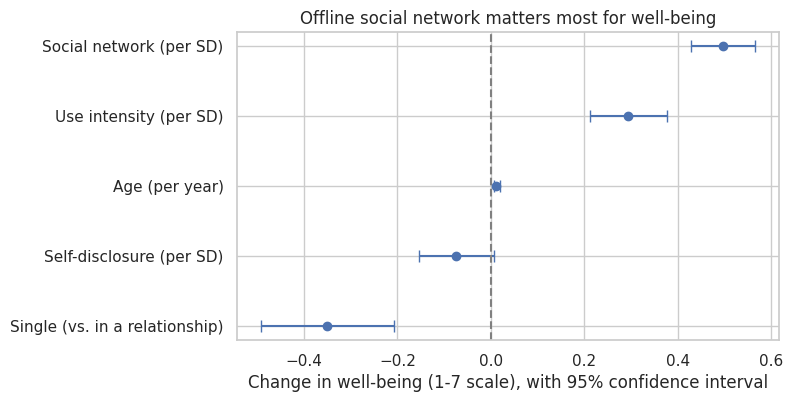

In [5]:
coefs = results.drop("Intercept").copy()
coefs.index = ["Self-disclosure (per SD)", "Social network (per SD)",
               "Use intensity (per SD)", "Age (per year)", "Single (vs. in a relationship)"]
coefs = coefs.sort_values("coef")

plt.figure(figsize=(7, 4))
plt.errorbar(coefs["coef"], coefs.index,
             xerr=[coefs["coef"] - coefs["ci_low"], coefs["ci_high"] - coefs["coef"]],
             fmt="o", capsize=4)
plt.axvline(0, color="grey", linestyle="--")
plt.xlabel("Change in well-being (1-7 scale), with 95% confidence interval")
plt.title("Offline social network matters most for well-being")
save_fig("rq3_coefficients.png")
plt.show()

**Step 4: Checking the model.** Linear regression assumes that the residuals (prediction errors) are roughly normally distributed and spread evenly across predicted values.

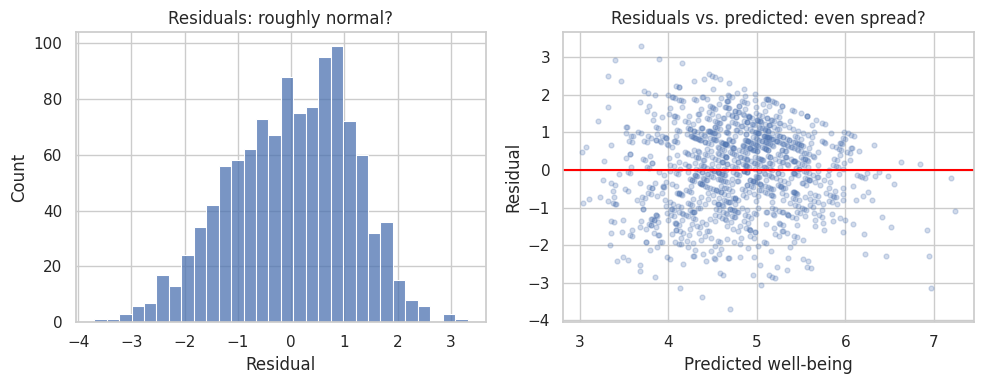

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(model.resid, bins=30, ax=axes[0])
axes[0].set_title("Residuals: roughly normal?")
axes[0].set_xlabel("Residual")
axes[1].scatter(model.fittedvalues, model.resid, alpha=0.25, s=12)
axes[1].axhline(0, color="red")
axes[1].set_title("Residuals vs. predicted: even spread?")
axes[1].set_xlabel("Predicted well-being")
axes[1].set_ylabel("Residual")
plt.tight_layout()
plt.show()

**Step 5: Does self-disclosure matter differently for companion users?** We add an interaction term (self_disclosure × companionship_prim) to test whether the effect of sharing personal information depends on using the chatbot as a companion.

In [7]:
model2 = smf.ols("well_being ~ self_disclosure * companionship_prim + social_network_scale "
                 "+ intensity + age + single", data=df).fit()
pd.DataFrame({"coef": model2.params, "p": model2.pvalues}).round(3)

,coef,p
Intercept,4.604,0.000
self_disclosure,-0.030,0.491
companionship_prim,-0.246,0.032
self_disclosure:companionship_prim,-0.263,0.021
social_network_scale,0.481,0.000
intensity,0.292,0.000
age,0.012,0.000
single,-0.360,0.000


**Interpretation.** The five predictors together explain about 25% of the variation in well-being (R² = 0.255). The offline social network is the strongest predictor: one standard deviation larger network goes with 0.50 points higher well-being (p < 0.001). More intensive use (+0.29) and higher age (+0.12 per 10 years) also go with higher well-being, being single with lower well-being (−0.35). Self-disclosure on its own is not significant (−0.07, p = 0.07). However, it depends on how the chatbot is used: among companion users, more self-disclosure goes with lower well-being (interaction −0.26, p = 0.02). The model assumptions are reasonably met. As with all our results, these are associations from a one-time survey, not proof of cause and effect.